# Анализ конверсии интернет-магазина: влияние акционных дней

**Цель:** выяснить, влияют ли акционные дни (5, 15, 25 числа месяца) на конверсию сессий в покупки.

**Описание полей:**

- `date` — дата
- `sessions` — количество сессий на сайте за день
- `cart_adds` — количество добавлений товара в корзину
- `purchases` — количество оформленных заказов

## Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Генерация данных

In [ ]:
np.random.seed(7)

dates = pd.date_range(datetime(2022, 3, 1), datetime(2024, 2, 29), freq='D')
n = len(dates)

# тренд роста, недельная сезонность, эффект акций
trend = np.linspace(0, 0.25, n)
dow_factor = [0.82 if d.weekday() >= 5 else 1.0 for d in dates]
promo_effect = [1.22 if d.day in [5, 15, 25] else 1.0 for d in dates]

sessions_list, cart_list, purchase_list = [], [], []

for i, d in enumerate(dates):
    s = int(900 * (1 + trend[i]) * dow_factor[i] * promo_effect[i] * np.random.normal(1, 0.09))
    sessions_list.append(max(80, s))

    cr = np.clip(0.14 * (1 + trend[i]*0.4) * promo_effect[i] * np.random.normal(1, 0.07), 0.03, 0.45)
    cart_list.append(int(sessions_list[-1] * cr))

    sr = np.clip(0.55 * (1 + trend[i]*0.2) * promo_effect[i] * np.random.normal(1, 0.07), 0.2, 0.85)
    purchase_list.append(int(cart_list[-1] * sr))

df = pd.DataFrame({'date': dates, 'sessions': sessions_list,
                   'cart_adds': cart_list, 'purchases': purchase_list})

# добавляем несколько аномальных значений
for idx in [10, 45, 200, 380, 500]:
    df.loc[idx, 'sessions'] = np.random.randint(2600, 3200)

print(f'Сгенерировано {len(df)} строк')
print(f'Период: {df["date"].min().date()} — {df["date"].max().date()}')
df.head()

Сгенерировано 731 строк
Период: 2022-03-01 — 2024-02-29


,date,sessions,cart_adds,purchases
0,2022-03-01,1036,140,77
1,2022-03-02,933,123,67
2,2022-03-03,900,110,64
3,2022-03-04,949,127,69
4,2022-03-05,942,158,104


## Описательная статистика

In [ ]:
df.describe()

,date,sessions,cart_adds,purchases
count,731,731.000000,731.000000,731.000000
mean,2023-03-01 00:00:00,997.674419,147.441860,84.871409
min,2022-03-01 00:00:00,615.000000,86.000000,44.000000
25%,2022-08-30 12:00:00,882.500000,125.000000,68.000000
50%,2023-03-01 00:00:00,980.000000,144.000000,79.000000
75%,2023-08-30 12:00:00,1078.500000,163.000000,92.000000
max,2024-02-29 00:00:00,2963.000000,294.000000,221.000000
std,NaN,214.966753,32.471532,25.584454


## Создание столбца год (year)

In [ ]:
df['year'] = df['date'].dt.year
print(df[['date', 'year']].head())

        date  year
0 2022-03-01  2022
1 2022-03-02  2022
2 2022-03-03  2022
3 2022-03-04  2022
4 2022-03-05  2022


## Конверсия сессий в покупки (conv_rate)

In [ ]:
df['conv_rate'] = (df['purchases'] / df['sessions']).round(2)

# вручную занижаем несколько значений для создания выбросов снизу
for idx in [15, 88, 300, 420]:
    df.loc[idx, 'conv_rate'] = round(np.random.uniform(0.01, 0.039), 2)

print(f'Средняя конверсия: {df["conv_rate"].mean():.2%}')
print(df[['date', 'sessions', 'purchases', 'conv_rate']].head())

Средняя конверсия: 8.43%
        date  sessions  purchases  conv_rate
0 2022-03-01      1036         77       0.07
1 2022-03-02       933         67       0.07
2 2022-03-03       900         64       0.07
3 2022-03-04       949         69       0.07
4 2022-03-05       942        104       0.11


## Фильтрация

Убираем строки где:
- `sessions > 2500` — аномально высокий трафик
- `conv_rate < 0.04` — технические сбои или ошибки данных

In [ ]:
print(f'До фильтрации: {len(df)} строк')

df = df[(df['sessions'] <= 2500) & (df['conv_rate'] >= 0.04)].copy()

print(f'После фильтрации: {len(df)} строк')

До фильтрации: 731 строк
После фильтрации: 723 строк


## Флаг акционного дня (promo_flag)

Акции проводятся 5, 15 и 25 числа каждого месяца.

In [ ]:
df['promo_flag'] = df['date'].dt.day.isin([5, 15, 25]).astype(int)

print(f'Акционных дней: {df["promo_flag"].sum()}')
print(f'Обычных дней: {(df["promo_flag"] == 0).sum()}')

Акционных дней: 70
Обычных дней: 653


## Агрегация по году и типу дня

1.   Новый пункт
2.   Новый пункт



Группируем по `year` и `promo_flag`, считаем среднюю конверсию.

In [ ]:
summary = df.groupby(['year', 'promo_flag']).agg(
    avg_conv_rate=('conv_rate', 'mean')
).round(4).reset_index()

summary['day_type'] = summary['promo_flag'].map({0: 'Обычный день', 1: 'Акционный день'})

print(summary[['year', 'day_type', 'avg_conv_rate']])

print()
for year in sorted(summary['year'].unique()):
    promo = summary[(summary['year'] == year) & (summary['promo_flag'] == 1)]['avg_conv_rate'].values[0]
    regular = summary[(summary['year'] == year) & (summary['promo_flag'] == 0)]['avg_conv_rate'].values[0]
    uplift = (promo - regular) / regular
    print(f'{year}: обычный = {regular:.2%}, акционный = {promo:.2%}, uplift = {uplift:+.1%}')

   year        day_type  avg_conv_rate
0  2022    Обычный день         0.0773
1  2022  Акционный день         0.1169
2  2023    Обычный день         0.0832
3  2023  Акционный день         0.1237
4  2024    Обычный день         0.0874
5  2024  Акционный день         0.1267

2022: обычный = 7.73%, акционный = 11.69%, uplift = +51.2%
2023: обычный = 8.32%, акционный = 12.37%, uplift = +48.7%
2024: обычный = 8.74%, акционный = 12.67%, uplift = +45.0%


## Обновление данных

Получены скорректированные данные за февраль 2024 и новые данные за март 2024.

Правила:
1. Если дата уже была — заменяем `sessions`, `cart_adds`, `purchases`
2. Если дата новая — добавляем строку
3. Если даты нет в корректировке — оставляем без изменений

In [ ]:
np.random.seed(99)

corr_dates = pd.date_range(datetime(2024, 2, 5), datetime(2024, 3, 21), freq='D')
df_corr = pd.DataFrame({
    'date': corr_dates,
    'sessions': np.random.randint(850, 1600, len(corr_dates)),
    'cart_adds': np.random.randint(80, 250, len(corr_dates)),
    'purchases': np.random.randint(40, 130, len(corr_dates))
})

print(f'Строк в корректировке: {len(df_corr)}')
# для корректного update нужен исходный df без фильтрации — загружаем заново
np.random.seed(7)
dates_raw = pd.date_range(datetime(2022, 3, 1), datetime(2024, 2, 29), freq='D')
n = len(dates_raw)
trend = np.linspace(0, 0.25, n)
dow_factor = [0.82 if d.weekday() >= 5 else 1.0 for d in dates_raw]
promo_effect = [1.22 if d.day in [5, 15, 25] else 1.0 for d in dates_raw]
s_list, c_list, p_list = [], [], []
for i, d in enumerate(dates_raw):
    s = int(900*(1+trend[i])*dow_factor[i]*promo_effect[i]*np.random.normal(1,0.09))
    s_list.append(max(80, s))
    cr = np.clip(0.14*(1+trend[i]*0.4)*promo_effect[i]*np.random.normal(1,0.07), 0.03, 0.45)
    c_list.append(int(s_list[-1]*cr))
    sr = np.clip(0.55*(1+trend[i]*0.2)*promo_effect[i]*np.random.normal(1,0.07), 0.2, 0.85)
    p_list.append(int(c_list[-1]*sr))
df_raw = pd.DataFrame({'date': dates_raw, 'sessions': s_list,
                       'cart_adds': c_list, 'purchases': p_list})
for idx in [10, 45, 200, 380, 500]:
    df_raw.loc[idx, 'sessions'] = np.random.randint(2600, 3200)

print(f'Пересечений: {df_raw["date"].isin(df_corr["date"]).sum()}')
print(f'Новых дат: {(~df_corr["date"].isin(df_raw["date"])).sum()}')

Строк в корректировке: 46
Пересечений: 25
Новых дат: 21


In [ ]:
df_m = df_raw.set_index('date').copy()
corr_idx = df_corr.set_index('date')[['sessions', 'cart_adds', 'purchases']]
df_m.update(corr_idx)

new_rows = corr_idx[~corr_idx.index.isin(df_m.index)].reset_index()
df_updated = pd.concat([df_m.reset_index(), new_rows], ignore_index=True)

# пересчёт и те же фильтры
df_updated['conv_rate'] = (df_updated['purchases'] / df_updated['sessions']).round(2)
for idx in [15, 88, 300, 420]:
    df_updated.loc[idx, 'conv_rate'] = round(np.random.uniform(0.01, 0.039), 2)
df_updated['year'] = df_updated['date'].dt.year
df_updated['promo_flag'] = df_updated['date'].dt.day.isin([5, 15, 25]).astype(int)
df_updated = df_updated[(df_updated['sessions'] <= 2500) & (df_updated['conv_rate'] >= 0.04)].copy()

print(f'Строк в обновлённом датафрейме: {len(df_updated)}')

Строк в обновлённом датафрейме: 743


## Сравнение агрегаций до и после обновления

In [ ]:
summary_new = df_updated.groupby(['year', 'promo_flag']).agg(
    avg_conv_rate=('conv_rate', 'mean')
).round(4).reset_index()

compare = summary.merge(summary_new, on=['year', 'promo_flag'], suffixes=('_old', '_new'))
compare['delta'] = (compare['avg_conv_rate_new'] - compare['avg_conv_rate_old']).round(4)
compare['day_type'] = compare['promo_flag'].map({0: 'Обычный', 1: 'Акционный'})

print('Абсолютное изменение avg_conv_rate (до → после):')
print(compare[['year', 'day_type', 'avg_conv_rate_old', 'avg_conv_rate_new', 'delta']].to_string(index=False))

Абсолютное изменение avg_conv_rate (до → после):
 year  day_type  avg_conv_rate_old  avg_conv_rate_new   delta
 2022   Обычный             0.0773             0.0773  0.0000
 2022 Акционный             0.1169             0.1169  0.0000
 2023   Обычный             0.0832             0.0832  0.0000
 2023 Акционный             0.1237             0.1237  0.0000
 2024   Обычный             0.0874             0.0781 -0.0093
 2024 Акционный             0.1267             0.0900 -0.0367


## Визуализация

/tmp/ipykernel_3034/4117500109.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(


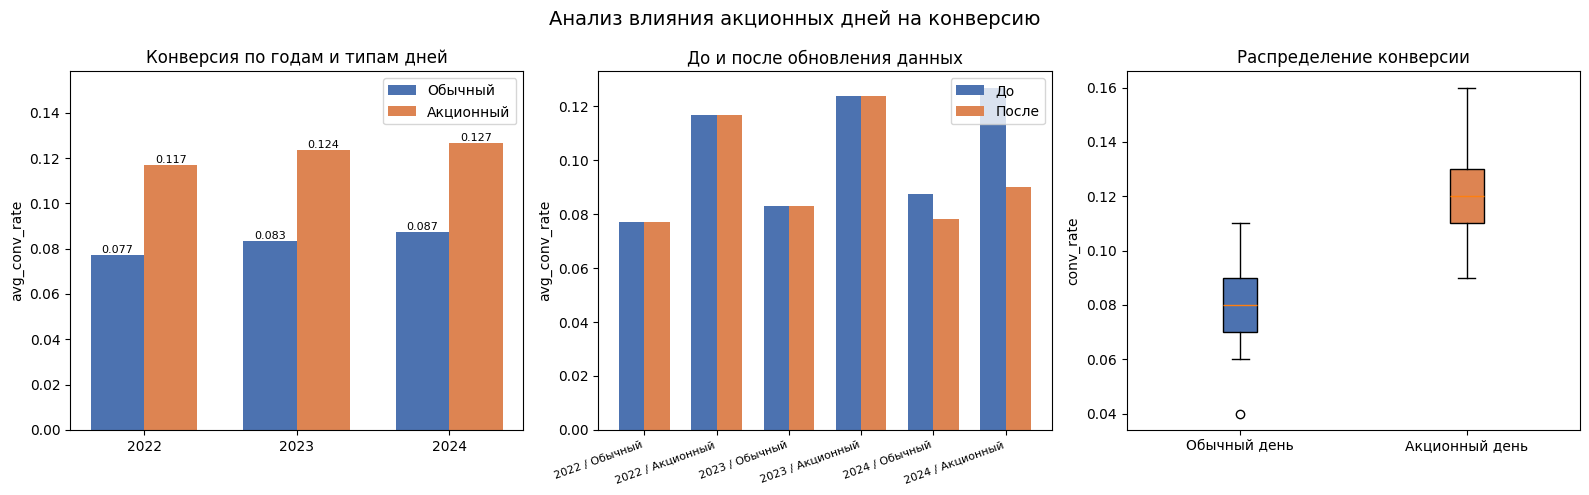

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Анализ влияния акционных дней на конверсию', fontsize=14)

# График 1: средняя конверсия по годам и типам дней
ax1 = axes[0]
years = sorted(compare['year'].unique())
x = np.arange(len(years))
width = 0.35

for i, year in enumerate(years):
    reg = compare[(compare['year'] == year) & (compare['promo_flag'] == 0)]['avg_conv_rate_old'].values[0]
    promo = compare[(compare['year'] == year) & (compare['promo_flag'] == 1)]['avg_conv_rate_old'].values[0]
    ax1.bar(i - width/2, reg, width, color='#4C72B0', label='Обычный' if i == 0 else '')
    ax1.bar(i + width/2, promo, width, color='#DD8452', label='Акционный' if i == 0 else '')
    ax1.text(i - width/2, reg + 0.001, f'{reg:.3f}', ha='center', fontsize=8)
    ax1.text(i + width/2, promo + 0.001, f'{promo:.3f}', ha='center', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.set_ylabel('avg_conv_rate')
ax1.set_title('Конверсия по годам и типам дней')
ax1.legend()
ax1.set_ylim(0, compare['avg_conv_rate_old'].max() * 1.25)

# График 2: до/после корректировки
ax2 = axes[1]
compare['label'] = compare['year'].astype(str) + ' / ' + compare['day_type']
x2 = np.arange(len(compare))
ax2.bar(x2 - width/2, compare['avg_conv_rate_old'], width, label='До', color='#4C72B0')
ax2.bar(x2 + width/2, compare['avg_conv_rate_new'], width, label='После', color='#DD8452')
ax2.set_xticks(x2)
ax2.set_xticklabels(compare['label'], rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('avg_conv_rate')
ax2.set_title('До и после обновления данных')
ax2.legend()

# График 3: boxplot
ax3 = axes[2]
bp = ax3.boxplot(
    [df[df['promo_flag'] == 0]['conv_rate'],
     df[df['promo_flag'] == 1]['conv_rate']],
    labels=['Обычный день', 'Акционный день'],
    patch_artist=True
)
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')
ax3.set_ylabel('conv_rate')
ax3.set_title('Распределение конверсии')

plt.tight_layout()
plt.savefig('sales_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Вывод

In [ ]:
print('ИТОГИ:')
print()
for year in sorted(summary['year'].unique()):
    promo = summary[(summary['year'] == year) & (summary['promo_flag'] == 1)]['avg_conv_rate'].values[0]
    regular = summary[(summary['year'] == year) & (summary['promo_flag'] == 0)]['avg_conv_rate'].values[0]
    uplift = (promo - regular) / regular
    print(f'{year}: обычный = {regular:.2%}, акционный = {promo:.2%}, uplift = {uplift:+.1%}')
print()
print('Изменение после обновления данных:')
print(compare[['year', 'day_type', 'avg_conv_rate_old', 'avg_conv_rate_new', 'delta']].to_string(index=False))

ИТОГИ:

2022: обычный = 7.73%, акционный = 11.69%, uplift = +51.2%
2023: обычный = 8.32%, акционный = 12.37%, uplift = +48.7%
2024: обычный = 8.74%, акционный = 12.67%, uplift = +45.0%

Изменение после обновления данных:
 year  day_type  avg_conv_rate_old  avg_conv_rate_new   delta
 2022   Обычный             0.0773             0.0773  0.0000
 2022 Акционный             0.1169             0.1169  0.0000
 2023   Обычный             0.0832             0.0832  0.0000
 2023 Акционный             0.1237             0.1237  0.0000
 2024   Обычный             0.0874             0.0781 -0.0093
 2024 Акционный             0.1267             0.0900 -0.0367
